# Backtesting with zipline - Pipeline API with Custom Data

> This notebook requires the `conda` environment `backtest`. Please see the [installation instructions](../installation/README.md) for running the latest Docker image or alternative ways to set up your environment.

## Imports & Settings

In [1]:
import warnings

warnings.filterwarnings("ignore")

In [96]:
from pathlib import Path
from time import time

import numpy as np
import pandas as pd
import pandas_datareader.data as web
from logbook import Logger, StderrHandler, INFO, WARNING

from zipline import run_algorithm
from zipline.api import (
    attach_pipeline,
    pipeline_output,
    date_rules,
    time_rules,
    record,
    schedule_function,
    commission,
    slippage,
    set_slippage,
    set_commission,
    set_max_leverage,
    order_target,
    order_target_percent,
    get_open_orders,
    cancel_order,
)
from zipline.finance import slippage
from zipline.data import bundles
from zipline.utils.run_algo import load_extensions
from zipline.pipeline import Pipeline, CustomFactor
from zipline.pipeline.data import Column, DataSet
from zipline.pipeline.domain import US_EQUITIES
from zipline.pipeline.filters import StaticAssets
from zipline.pipeline.loaders import USEquityPricingLoader
from zipline.pipeline.loaders.frame import DataFrameLoader

import pyfolio as pf
from pyfolio.plotting import plot_rolling_returns, plot_rolling_sharpe
from pyfolio.timeseries import forecast_cone_bootstrap

from alphalens.tears import (
    create_returns_tear_sheet,
    create_summary_tear_sheet,
    create_full_tear_sheet,
)

from alphalens.performance import mean_return_by_quantile
from alphalens.plotting import plot_quantile_returns_bar
from alphalens.utils import get_clean_factor_and_forward_returns, rate_of_return

import matplotlib.pyplot as plt
import seaborn as sns

In [4]:
sns.set_style("whitegrid")

np.random.seed(42)
idx = pd.IndexSlice

In [5]:
results_path = Path("results")

## Alphalens Analysis

In [6]:
DATA_STORE = Path("..", "data", "assets.h5")

In [ ]:
def get_trade_prices(tickers):
    prices = pd.read_hdf(DATA_STORE, "quandl/wiki/prices").swaplevel().sort_index()
    prices.index.names = ["symbol", "date"]
    prices = prices.loc[idx[tickers, "2015":"2018"], "adj_open"]
    return prices.unstack("symbol").sort_index().shift(-1).tz_localize("UTC")

In [57]:
predictions = (
    pd.read_hdf(results_path / "test_preds.h5", "predictions")
    .iloc[:, :3]
    .mean(1)
    .to_frame("prediction")
)

In [58]:
factor = (
    predictions.unstack("symbol")
    .asfreq("D")
    #        .dropna(how='all')
    .stack()
    #       .tz_localize('UTC', level='date')
    .sort_index()
)
tickers = factor.index.get_level_values("symbol").unique()

In [59]:
trade_prices = get_trade_prices(tickers)

In [60]:
factor_data = get_clean_factor_and_forward_returns(
    factor=factor,
    prices=trade_prices,
    quantiles=5,
    max_loss=0.3,
    periods=(1, 5, 10, 21),
).sort_index()
factor_data.info()

Dropped 3.1% entries from factor data: 3.1% in forward returns computation and 0.0% in binning phase (set max_loss=0 to see potentially suppressed Exceptions).
max_loss is 30.0%, not exceeded: OK!
<class 'pandas.core.frame.DataFrame'>
MultiIndex: 726069 entries, (Timestamp('2015-01-02 00:00:00'), 'A') to (Timestamp('2017-11-29 00:00:00'), 'ZION')
Data columns (total 6 columns):
 #   Column           Non-Null Count   Dtype  
---  ------           --------------   -----  
 0   1D               726069 non-null  float64
 1   7D               726069 non-null  float64
 2   15D              726069 non-null  float64
 3   30D              726069 non-null  float64
 4   factor           726069 non-null  float32
 5   factor_quantile  726069 non-null  int64  
dtypes: float32(1), float64(4), int64(1)
memory usage: 33.4+ MB


Quantiles Statistics


,min,max,mean,std,count,count %
factor_quantile,,,,,,
1,-0.035616,0.010313,-0.001617,0.002296,145357,20.019723
2,-0.008511,0.011062,-0.000482,0.001965,145150,19.991213
3,-0.006818,0.011505,0.000155,0.001937,145131,19.988596
4,-0.005142,0.011985,0.000826,0.001967,145150,19.991213
5,-0.003495,0.029541,0.002430,0.002764,145281,20.009255


Returns Analysis


,1D,7D,15D,30D
Ann. alpha,0.112,0.044,0.045,0.040
beta,0.140,0.209,0.241,0.221
Mean Period Wise Return Top Quantile (bps),5.734,2.937,3.028,2.627
Mean Period Wise Return Bottom Quantile (bps),-4.157,-1.970,-2.186,-2.043
Mean Period Wise Spread (bps),9.891,4.886,5.191,4.651


Information Analysis


,1D,7D,15D,30D
IC Mean,0.02,0.029,0.048,0.060
IC Std.,0.13,0.138,0.142,0.131
Risk-Adjusted IC,0.15,0.209,0.337,0.461
t-stat(IC),NaN,NaN,NaN,NaN
p-value(IC),NaN,NaN,NaN,NaN
IC Skew,NaN,NaN,NaN,NaN
IC Kurtosis,NaN,NaN,NaN,NaN


Turnover Analysis


,1D,7D,15D,30D
Quantile 1 Mean Turnover,0.440,0.558,0.639,0.715
Quantile 2 Mean Turnover,0.652,0.718,0.749,0.772
Quantile 3 Mean Turnover,0.679,0.740,0.769,0.783
Quantile 4 Mean Turnover,0.638,0.713,0.750,0.775
Quantile 5 Mean Turnover,0.400,0.520,0.597,0.655


,1D,7D,15D,30D
Mean Factor Rank Autocorrelation,0.65,0.473,0.343,0.219


<Figure size 640x480 with 0 Axes>

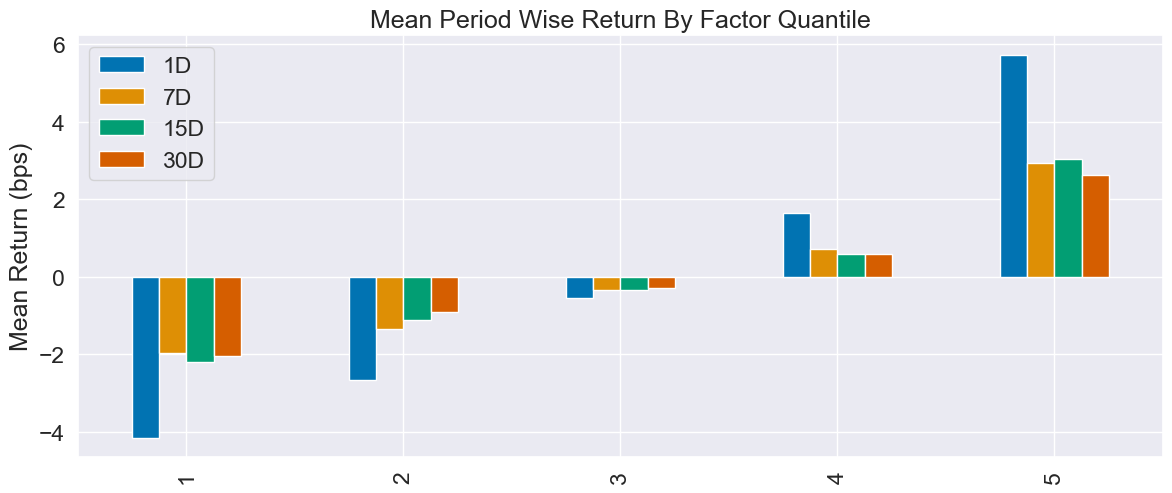

In [61]:
create_summary_tear_sheet(factor_data)

### Load zipline extensions

Only need this in notebook to find bundle.

In [62]:
load_extensions(default=True, extensions=[], strict=True, environ=None)

In [63]:
log_handler = StderrHandler(
    format_string="[{record.time:%Y-%m-%d %H:%M:%S.%f}]: "
    + "{record.level_name}: {record.func_name}: {record.message}",
    level=WARNING,
)
log_handler.push_application()
log = Logger("Algorithm")

## Algo Params

In [64]:
N_LONGS = 25
N_SHORTS = 25
MIN_POSITIONS = 10

## Load Data

### Quandl Wiki Bundel

In [65]:
bundle_data = bundles.load("quandl")

### ML Predictions

In [66]:
def load_predictions(bundle):
    predictions = (
        pd.read_hdf(results_path / "test_preds.h5", "predictions")
        .iloc[:, :3]
        .mean(1)
        .to_frame("prediction")
    )
    tickers = predictions.index.get_level_values("symbol").unique().tolist()

    assets = bundle.asset_finder.lookup_symbols(tickers, as_of_date=None)
    predicted_sids = pd.Index([asset.sid for asset in assets], dtype="int64")
    ticker_map = dict(zip(tickers, predicted_sids))

    return (predictions.unstack("symbol").rename(columns=ticker_map).prediction), assets

In [67]:
predictions, assets = load_predictions(bundle_data)

In [68]:
predictions.info()

<class 'pandas.core.frame.DataFrame'>
DatetimeIndex: 756 entries, 2017-08-30 to 2015-03-02
Columns: 995 entries, 0 to 2531
dtypes: float32(995)
memory usage: 2.9 MB


### Define Custom Dataset

In [69]:
class SignalData(DataSet):
    predictions = Column(dtype=float)
    domain = US_EQUITIES

### Define Pipeline Loaders

In [70]:
signal_loader = {
    SignalData.predictions: DataFrameLoader(SignalData.predictions, predictions)
}

## Pipeline Setup

### Custom ML Factor

In [72]:
class MLSignal(CustomFactor):
    """Converting signals to Factor
    so we can rank and filter in Pipeline"""

    inputs = [SignalData.predictions]
    window_length = 1

    def compute(self, today, assets, out, predictions):
        out[:] = predictions

### Create Pipeline

In [73]:
def compute_signals():
    signals = MLSignal()
    return Pipeline(
        columns={
            "longs": signals.top(N_LONGS, mask=signals > 0),
            "shorts": signals.bottom(N_SHORTS, mask=signals < 0),
        },
        screen=StaticAssets(assets),
    )

In [108]:
def compute_signals():
    signals = MLSignal()
    return Pipeline(
        columns={
            "signal": signals,  # <-- Add this line
            "longs": signals.top(N_LONGS, mask=signals > 0),
            "shorts": signals.bottom(N_SHORTS, mask=signals < 0),
        },
        screen=StaticAssets(assets),
    )

## Initialize Algorithm

In [97]:
def initialize(context):
    """
    Called once at the start of the algorithm.
    """
    context.longs = context.shorts = None
    set_slippage(
        slippage.VolumeShareSlippage(
            volume_limit=0.025,  # Max 2.5% of daily volume per trade
            price_impact=0.1,  # 10% price impact coefficient (tune as needed)
        )
    )
    set_commission(commission.PerShare(cost=0.001, min_trade_cost=0))

    schedule_function(
        rebalance, date_rules.week_start(), time_rules.market_open(hours=1, minutes=30)
    )

    schedule_function(record_vars, date_rules.every_day(), time_rules.market_close())

    pipeline = compute_signals()
    attach_pipeline(pipeline, "signals")

### Get daily Pipeline results

In [109]:
def before_trading_start(context, data):
    """
    Called every day before market open.
    """
    output = pipeline_output("signals")
    longs = pipeline_output("signals").longs.astype(int)
    shorts = pipeline_output("signals").shorts.astype(int)
    holdings = context.portfolio.positions.keys()

    # Store the raw signal for all assets in the pipeline output
    context.signal_data = output.signal  # <-- Add this line

    if longs.sum() > MIN_POSITIONS and shorts.sum() > MIN_POSITIONS:
        context.longs = longs[longs != 0].index
        context.shorts = shorts[shorts != 0].index
        context.divest = holdings - set(context.longs) - set(context.shorts)
    else:
        context.longs = context.shorts = pd.Index([])
        context.divest = set(holdings)

## Define Rebalancing Logic

In [101]:
def rebalance(context, data):
    """
    Execute orders according to schedule_function() date & time rules.
    """

    for symbol, open_orders in get_open_orders().items():
        for open_order in open_orders:
            cancel_order(open_order)

    for stock in context.divest:
        order_target(stock, target=0)

    #     log.warning('{} {:,.0f}'.format(len(context.portfolio.positions), context.portfolio.portfolio_value))
    if not (context.longs.empty and context.shorts.empty):
        for stock in context.shorts:
            order_target_percent(stock, -1 / len(context.shorts))
        for stock in context.longs:
            order_target_percent(stock, 1 / len(context.longs))

In [110]:
def rebalance(context, data):
    # Cancel open orders
    for symbol, open_orders in get_open_orders().items():
        for open_order in open_orders:
            cancel_order(open_order)
    for stock in context.divest:
        order_target(stock, target=0)

    # Only rebalance if there are positions to take
    if not (context.longs.empty and context.shorts.empty):
        # Get signals for current longs and shorts
        signals = context.signal_data
        long_signals = signals.loc[context.longs]
        short_signals = signals.loc[context.shorts]

        # Normalize weights by absolute signal strength
        long_weights = (
            long_signals / long_signals.abs().sum()
            if not long_signals.empty
            else pd.Series()
        )
        short_weights = (
            short_signals / short_signals.abs().sum()
            if not short_signals.empty
            else pd.Series()
        )

        # Cap max position size (e.g., 5%)
        max_pos = 0.05
        long_weights = long_weights.clip(upper=max_pos)
        short_weights = short_weights.clip(lower=-max_pos)

        total_weight = long_weights.abs().sum() + short_weights.abs().sum()
        max_leverage = 2.0
        if total_weight > max_leverage:
            scale = max_leverage / total_weight
            long_weights *= scale
            short_weights *= scale

        # Place orders
        for stock, weight in long_weights.items():
            order_target_percent(stock, weight)
        for stock, weight in short_weights.items():
            order_target_percent(stock, weight)  # weight is negative for shorts

In [98]:
def exec_trades(data, assets, target_percents, min_trade_value=1000):
    """
    Place orders for assets using target portfolio percentage.
    Only place orders if the trade value exceeds min_trade_value.
    """
    for asset, target_percent in target_percents.items():
        if data.can_trade(asset) and not get_open_orders(asset):
            current_price = data.current(asset, "price")
            trade_value = context.portfolio.portfolio_value * abs(target_percent)
            if trade_value >= min_trade_value:
                order_target_percent(asset, target_percent)

## Record Data Points

In [77]:
def record_vars(context, data):
    """
    Plot variables at the end of each day.
    """
    record(
        leverage=context.account.leverage, longs=context.longs, shorts=context.shorts
    )

## Run Algorithm

In [78]:
dates = predictions.index.get_level_values("date")
start_date, end_date = dates.min(), dates.max()

In [79]:
print("Start: {}\nEnd:   {}".format(start_date.date(), end_date.date()))

Start: 2014-11-28
End:   2017-11-29


In [111]:
start = time()
results = run_algorithm(
    start=start_date,
    end=end_date,
    initialize=initialize,
    before_trading_start=before_trading_start,
    capital_base=1e5,
    data_frequency="daily",
    bundle="quandl",
    custom_loader=signal_loader,
)  # need to modify zipline

print("Duration: {:.2f}s".format(time() - start))

Duration: 97.36s


In [112]:
results

,period_open,period_close,positions,shorts_count,returns,portfolio_value,long_value,short_value,long_exposure,starting_cash,...,alpha,beta,sharpe,sortino,max_drawdown,max_leverage,excess_return,treasury_period_return,trading_days,period_label
2014-11-28 18:00:00+00:00,2014-11-28 14:31:00+00:00,2014-11-28 18:00:00+00:00,[],0,0.000000,100000.000000,0.00,0.00,0.00,100000.000000,...,None,None,NaN,NaN,0.000000,0.000000,0.0,0.0,1,2014-11
2014-12-01 21:00:00+00:00,2014-12-01 14:31:00+00:00,2014-12-01 21:00:00+00:00,[],0,0.000000,100000.000000,0.00,0.00,0.00,100000.000000,...,None,None,NaN,NaN,0.000000,0.000000,0.0,0.0,2,2014-12
2014-12-02 21:00:00+00:00,2014-12-02 14:31:00+00:00,2014-12-02 21:00:00+00:00,"[{'sid': Equity(192 [APA]), 'amount': 43, 'cos...",25,-0.000067,99993.306576,95247.71,-98976.06,95247.71,100000.000000,...,None,None,-9.165151,-9.165151,-0.000067,1.942368,0.0,0.0,3,2014-12
2014-12-03 21:00:00+00:00,2014-12-03 14:31:00+00:00,2014-12-03 21:00:00+00:00,"[{'sid': Equity(192 [APA]), 'amount': 43, 'cos...",25,0.009998,100993.046576,96990.33,-99718.94,96990.33,103721.656576,...,None,None,7.866405,1177.662356,-0.000067,1.947751,0.0,0.0,4,2014-12
2014-12-04 21:00:00+00:00,2014-12-04 14:31:00+00:00,2014-12-04 21:00:00+00:00,"[{'sid': Equity(192 [APA]), 'amount': 43, 'cos...",25,-0.012008,99780.316576,95588.91,-99530.25,95588.91,103721.656576,...,None,None,-0.845497,-1.227879,-0.012008,1.955487,0.0,0.0,5,2014-12
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
2017-11-22 21:00:00+00:00,2017-11-22 14:31:00+00:00,2017-11-22 21:00:00+00:00,"[{'sid': Equity(45 [ADBE]), 'amount': -30, 'co...",25,0.015490,216782.110615,211456.37,-196461.94,211456.37,201787.680615,...,None,None,1.242340,1.946348,-0.237893,2.085441,0.0,0.0,753,2017-11
2017-11-24 18:00:00+00:00,2017-11-24 14:31:00+00:00,2017-11-24 18:00:00+00:00,"[{'sid': Equity(45 [ADBE]), 'amount': -30, 'co...",25,-0.007546,215146.190615,211283.61,-197925.10,211283.61,201787.680615,...,None,None,1.230232,1.926982,-0.237893,2.085441,0.0,0.0,754,2017-11
2017-11-27 21:00:00+00:00,2017-11-27 14:31:00+00:00,2017-11-27 21:00:00+00:00,"[{'sid': Equity(45 [ADBE]), 'amount': -30, 'co...",25,0.002338,215649.240615,211207.95,-197346.39,211207.95,201787.680615,...,None,None,1.232815,1.931035,-0.237893,2.085441,0.0,0.0,755,2017-11
2017-11-28 21:00:00+00:00,2017-11-28 14:31:00+00:00,2017-11-28 21:00:00+00:00,"[{'sid': Equity(122 [ALGN]), 'amount': -26, 'c...",25,0.001484,215969.328671,205093.20,-200360.28,205093.20,201787.680615,...,None,None,1.234158,1.933139,-0.237893,2.085441,0.0,0.0,756,2017-11


## PyFolio Analysis

In [113]:
returns, positions, transactions = pf.utils.extract_rets_pos_txn_from_zipline(results)

In [85]:
benchmark = web.DataReader("SP500", "fred", "2014", "2018").squeeze()
benchmark = benchmark.pct_change().tz_localize("UTC")

### Custom Plots

In [87]:
LIVE_DATE = "2016-11-30"

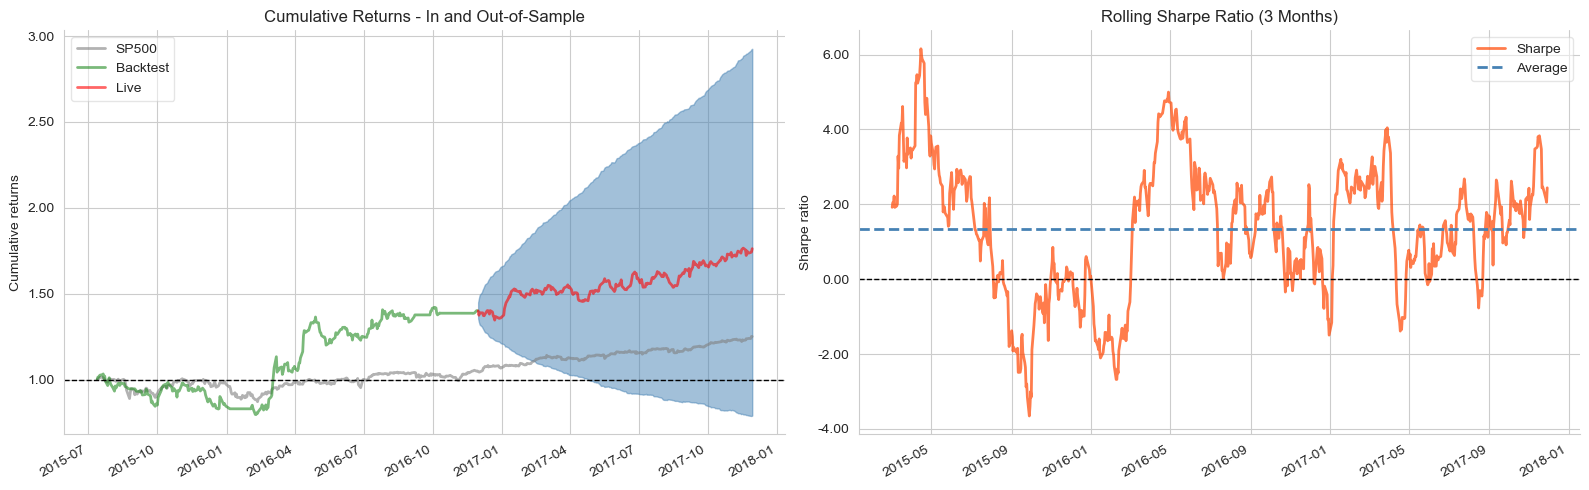

In [114]:
fig, axes = plt.subplots(ncols=2, figsize=(16, 5))
plot_rolling_returns(
    returns.loc["2015-07-13":,],
    factor_returns=benchmark,
    live_start_date=LIVE_DATE,
    logy=False,
    cone_std=2,
    legend_loc="best",
    volatility_match=False,
    cone_function=forecast_cone_bootstrap,
    ax=axes[0],
)
plot_rolling_sharpe(returns, ax=axes[1], rolling_window=63)
axes[0].set_title("Cumulative Returns - In and Out-of-Sample")
axes[1].set_title("Rolling Sharpe Ratio (3 Months)")
sns.despine()
fig.tight_layout()
fig.savefig((results_path / "pyfolio_out_of_sample").as_posix(), dpi=300)

### Tear Sheets

Worst drawdown periods,Net drawdown in %,Peak date,Valley date,Recovery date,Duration
0,22.94,2015-07-21,2016-02-09,2016-03-04,164
1,12.01,2016-04-28,2016-05-12,2016-07-26,64
2,9.10,2016-03-07,2016-03-15,2016-04-11,26
3,6.19,2017-03-29,2017-04-17,2017-05-12,33
4,5.67,2017-07-26,2017-08-16,2017-09-01,28


Stress Events,mean,min,max
Fall2015,-0.40%,-3.93%,3.32%
New Normal,0.10%,-7.94%,8.32%


Top 10 long positions of all time,max
sid,
WLL,8.07%
SM,7.55%
EXAS,7.25%
VRX,6.51%
MAT,6.48%
CLF,6.35%
CHK,6.30%
XPO,6.11%
ALNY,5.99%


Top 10 short positions of all time,max
sid,
VRX,-6.36%
NKTR,-6.19%
NRG,-6.13%
X,-6.13%
KBR,-6.10%
GOLD,-6.03%
CLF,-5.90%
OAS,-5.68%
ESV,-5.66%


Top 10 positions of all time,max
sid,
WLL,8.07%
SM,7.55%
EXAS,7.25%
VRX,6.51%
MAT,6.48%
CLF,6.35%
CHK,6.30%
NKTR,6.19%
NRG,6.13%


...

PnL stats,All trades,Short trades,Long trades
Total profit,$80506.74,$-20176.26,$100682.99
Gross profit,$632938.75,$241964.58,$390974.17
Gross loss,$-552432.02,$-262140.84,$-290291.18
Profit factor,$1.15,$0.92,$1.35
Avg. trade net profit,$16.16,$-7.75,$42.37
Avg. winning trade,$259.08,$208.41,$304.97
Avg. losing trade,$-217.66,$-181.54,$-265.35
Ratio Avg. Win:Avg. Loss,$1.19,$1.15,$1.15
Largest winning trade,$5842.84,$5842.84,$4538.48
Largest losing trade,$-4771.21,$-4597.95,$-4771.21


Duration stats,All trades,Short trades,Long trades
Avg duration,16 days 17:00:20.966472595,15 days 20:09:01.735124760,17 days 15:52:16.369528619
Median duration,7 days 00:00:00,7 days 00:00:00,7 days 00:00:00
Longest duration,840 days 00:00:00,763 days 00:00:00,840 days 00:00:00
Shortest duration,0 days 03:00:01,0 days 03:00:01,0 days 03:00:01


Return stats,All trades,Short trades,Long trades
Avg returns all round_trips,0.01%,-0.00%,0.03%
Avg returns winning,0.17%,0.14%,0.19%
Avg returns losing,-0.13%,-0.11%,-0.17%
Median returns all round_trips,-0.00%,-0.01%,0.01%
Median returns winning,0.09%,0.07%,0.10%
Median returns losing,-0.07%,-0.06%,-0.08%
Largest winning trade,5.02%,5.02%,3.11%
Largest losing trade,-3.99%,-2.45%,-3.99%


Symbol stats,A,AAL,AAN,AAP,AAPL,ABC,ABMD,ABT,ACGL,ACM,ACN,ACXM,ADBE,ADI,ADM,ADP,ADS,ADSK,AEE,AEL,AEO,AEP,AET,AFG,AFL,AFSI,AGN,AGNC,AGO,AHL,AIV,AIZ,AJG,AKAM,ALB,ALE,ALGN,ALK,ALKS,ALL,ALNY,ALXN,AMAT,AMD,AMED,AMP,AMT,AMTD,AMZN,AN,ANAT,ANSS,ANTM,AON,AOS,APA,APC,APD,APH,ARNC,ARRS,ARRY,ARW,ASGN,ASH,ATHN,ATI,ATO,ATR,ATVI,AVA,AVB,AVGO,AVT,AVX,AVY,AWI,AWK,AXP,AXS,AYI,AZO,AZPN,B,BA,BAC,BAH,BAX,BBT,BBY,BC,BCPC,BDC,BDN,BDX,BECN,BEN,BG,BGCP,BID,BIDU,BIIB,BIO,BK,BKH,BLK,BLKB,BLL,BMRN,BMS,BMY,BOFI,BOH,BOKF,BP,BPOP,BR,BRKR,BRO,BSX,BWA,BXP,BXS,BYD,C,CA,CACC,CACI,CAG,CAH,CAKE,CAR,CASY,CAT,CATY,CAVM,CB,CBOE,CBRL,CBSH,CBT,CBU,CCE,CCI,CCK,CCL,CCMP,CCOI,CDNS,CE,CELG,CERN,CF,CFR,CFX,CHD,CHDN,CHE,CHFC,CHH,CHK,CHKP,CHRW,CHTR,CI,CIEN,CIM,CINF,CL,CLF,CLGX,CLH,CLNY,CLR,CLX,CMA,CMC,CMCSA,CME,CMG,CMI,CMS,CNA,CNC,CNK,CNO,CNP,CNX,COF,COG,COHR,COL,COLB,COLM,COP,COR,COST,CPA,CPB,CPRT,CPT,CR,CREE,CRI,CRL,CRM,CRS,CSCO,CSFL,CSGP,CSL,CSX,CTAS,CTL,CTSH,CTXS,CUBE,CUZ,CVBF,CVI,CVLT,CVS,CVX,CW,CXO,CXW,CY,D,DAL,DAN,DAR,DCI,DCT,DDS,DE,DECK,DEI,DFS,DG,DGX,DHI,DHR,DIS,DISCA,DISCK,DISH,DK,DKS,DLB,DLR,DLTR,DLX,DNB,DO,DOX,DPS,DPZ,DRE,DRH,DRI,DTE,DUK,DVA,DVN,DXCM,DY,EA,EBAY,EBIX,EBS,ECL,ED,EDR,EE,EEFT,EFX,EGN,EIX,ELS,EME,EMN,EMR,ENR,ENS,ENTG,ENV,EOG,EPR,EQIX,EQR,EQT,ERIE,ES,ESGR,ESRX,ESS,ESV,ETFC,ETN,ETR,EVR,EW,EWBC,EXAS,EXC,EXEL,EXP,EXPE,EXPO,EXR,F,FAF,FAST,FCFS,FCNCA,FCX,FDS,FDX,FFBC,FFIN,FFIV,FIBK,FICO,FIS,FISV,FITB,FIZZ,FL,FLO,FLR,FLT,FMBI,FMC,FNB,FNF,FNGN,FOLD,FOX,FOXA,FR,FRT,FSLR,FTNT,FULT,G,GBCI,GD,GDOT,GE,GEO,GGP,GHC,GILD,GIS,GLNG,GLW,GM,GNRC,GNTX,GOLD,GOOGL,GPC,GPN,GPS,GPT,GRA,GRMN,GS,GT,GTT,GVA,GWR,GWW,H,HAE,HAIN,HAL,HALO,HAS,HBAN,HBI,HCP,HCSG,HD,HE,HEI,HELE,HES,HFC,HHC,HI,HIG,HLF,HOG,HOLX,HOMB,HON,HP,HPP,HPT,HR,HRB,HRL,HRTX,HSIC,HST,HSY,HUM,HUN,HXL,IART,IBKC,IBKR,IBM,IBOC,ICE,ICUI,IDA,IDCC,IDTI,IDXX,IEX,IFF,IGT,IIVI,ILMN,IMMU,INCY,INGR,INTC,INTU,IPG,IPGP,IRM,IRWD,ISBC,IT,ITRI,ITT,ITW,IVZ,JACK,JBHT,JBL,JBLU,JBT,JCI,JCOM,JJSF,JKHY,JLL,JNJ,JNPR,JPM,JWN,K,KBR,KEX,KEY,KFY,KIM,KLAC,KMB,KMPR,KMT,KMX,KNX,KO,KR,KRC,KRO,KS,KSS,KSU,KW,L,LAMR,LANC,LAZ,LB,LBTYA,LDOS,LEA,LECO,LEG,LFUS,LGND,LH,LHCG,LHO,LII,LKQ,LLL,LLY,LMT,LNC,LNG,LNT,LOGM,LOPE,LOW,LPLA,LPX,LRCX,LSI,LSTR,LUV,LVS,LYV,M,MA,MAA,MAC,MAN,MANH,MAR,MAS,MASI,MAT,MBFI,MCD,MCHP,MCK,MCO,MCY,MD,MDCO,MDLZ,MDP,MDR,MDSO,MDT,MDU,MET,MGLN,MGM,MIDD,MKC,MKL,MKSI,MKTX,MLM,MMC,MMM,MMS,MMSI,MNST,MO,MOH,MOS,MPW,MPWR,MRK,MRO,MRVL,MS,MSA,MSFT,MSG,MSI,MSM,MTB,MTG,MTN,MTX,MTZ,MU,MUR,MXIM,MYGN,MYL,NATI,NAV,NBIX,NBL,NCR,NDAQ,NDSN,NEE,NEM,NEOG,NEU,NFG,NFLX,NFX,NI,NJR,NKE,NKTR,NLY,NNI,NOC,NOV,NRG,NSC,NSP,NTAP,NTCT,NTRS,NUAN,NUE,NUS,NUVA,NVDA,NVR,NWE,NWL,NXST,NYCB,NYT,O,OAS,OC,ODFL,OFC,OGE,OHI,OI,OII,OKE,OLED,OLN,OMC,OPK,ORA,ORCL,ORI,ORLY,OSK,OXY,OZRK,PACW,PAG,PAY,PAYX,PB,PBCT,PCAR,PCG,PCH,PDCE,PDM,PEB,PEG,PEGA,PENN,PEP,PFE,PG,PGR,PII,PKG,PLD,PLT,PM,PNC,PNFP,PNM,PNW,PODD,POL,POOL,POR,PPC,PPG,PPL,PRGO,PRI,PRU,PSA,PSMT,PTEN,PVH,PWR,PXD,QCOM,QDEL,QGEN,R,RBC,RCL,RDN,RE,REG,REGN,RES,RF,RGA,RGLD,RHI,RHP,RHT,RIG,RL,RLI,RMD,RNR,ROL,ROP,ROST,RP,RPM,RRC,RS,RSG,RTN,S,SAM,SATS,SBAC,SBGI,SBNY,SBRA,SBUX,SCCO,SCG,SCHW,SCI,SE,SEB,SEIC,SEM,SF,SFLY,SFNC,SGEN,SGMS,SHO,SHOO,SHW,SIG,SIGI,SIRI,SIVB,SIX,SJI,SJM,SKX,SKYW,SLAB,SLB,SLG,SLGN,SLM,SM,SMG,SMTC,SNA,SNH,SNPS,SNX,SO,SON,SPG,SPR,SRCL,SRE,SSD,SSNC,STE,STI,STL,STLD,STMP,STT,STWD,STX,STZ,SUI,SWK,SWKS,SWN,SWX,SYK,SYMC,SYNT,SYY,T,TAL,TAP,TCBI,TCO,TDC,TDG,TDS,TDY,TECD,TECH,TEL,TER,TEX,TFSL,TFX,TGT,THC,THG,THO,THS,TJX,TMK,TMO,TMUS,TPX,TREE,TREX,TRGP,TRI,TRMB,TRN,TROX,TRV,TSCO,TSLA,TSN,TSS,TTC,TTEK,TTWO,TWO,TXN,TXRH,TXT,TYL,UAA,UAL,UBSH,UBSI,UDR,UFS,UGI,UHAL,UHS,ULTA,ULTI,UMBF,UNH,UNM,UNP,UPS,URBN,URI,USB,USG,USM,USNA,UTHR,UTX,V,VC,VG,VIAB,VLO,VMC,VMI,VMW,VNO,VOD,VR,VRNT,VRSK,VRSN,VRTX,VRX,VSAT,VSH,VTR,VVC,VZ,WAB,WAFD,WAL,WAT,WBA,WBC,WBS,WCC,WCG,WCN,WDC,WEC,WEN,WERN,WEX,WFC,WGL,WHR,WLK,WLL,WM,WMB,WMGI,WMT,WOR,WRB,WSM,WSO,WST,WTFC,WTM,WTR,WTS,WWE,WWW,WY,WYNN,X,XEC,XL,XLNX,XOM,XPO,XRAY,XRX,Y,YUM,ZBH,ZBRA,ZION
Avg returns all round_trips,-0.07%,0.18%,-0.11%,-0.01%,-0.00%,-0.03%,0.02%,-0.05%,-0.04%,-0.08%,0.02%,-0.02%,-0.04

Profitability (PnL / PnL total) per name,
symbol,
FOLD,13.55%
CLF,11.99%
BOFI,11.35%
EXAS,9.65%
OPK,6.98%
OAS,6.81%
MYGN,5.85%
EXEL,5.70%
CAR,5.62%


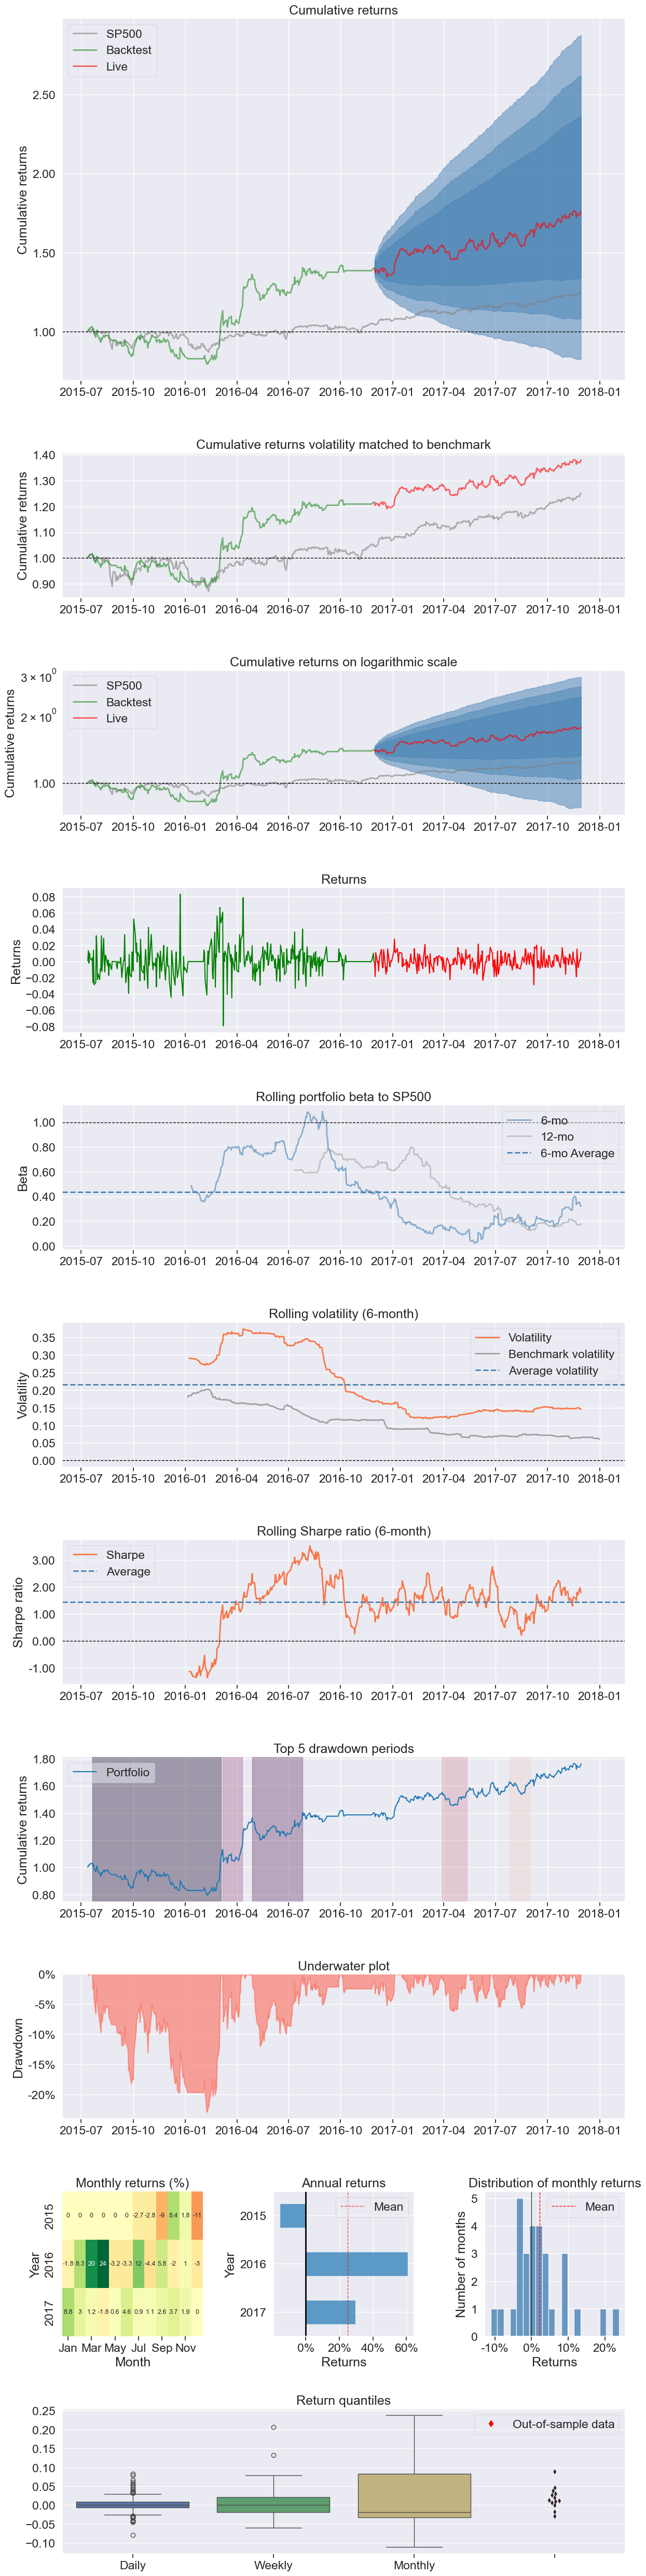

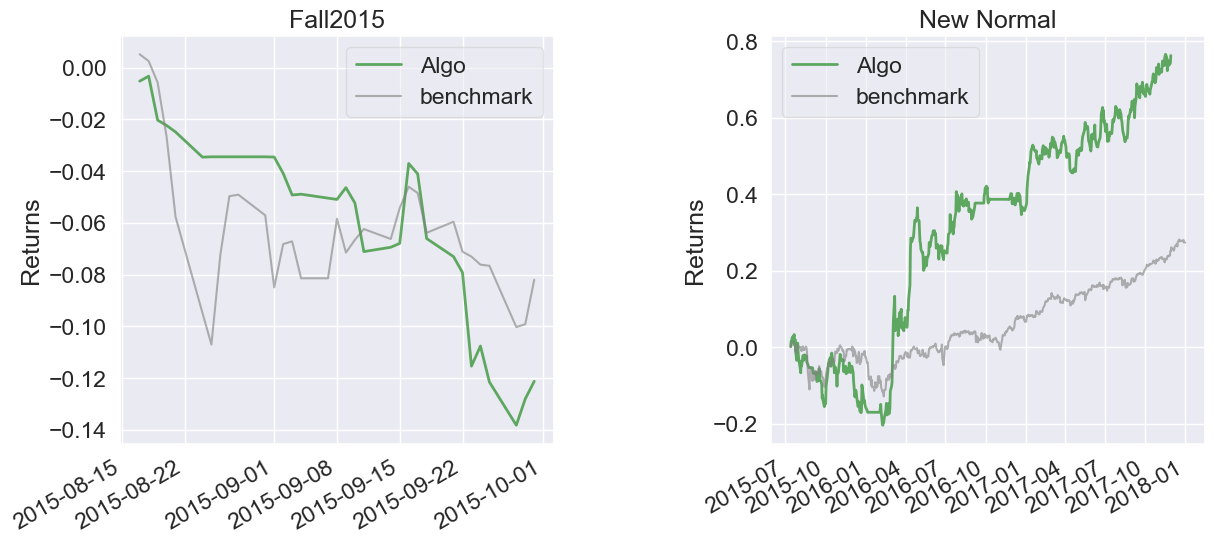

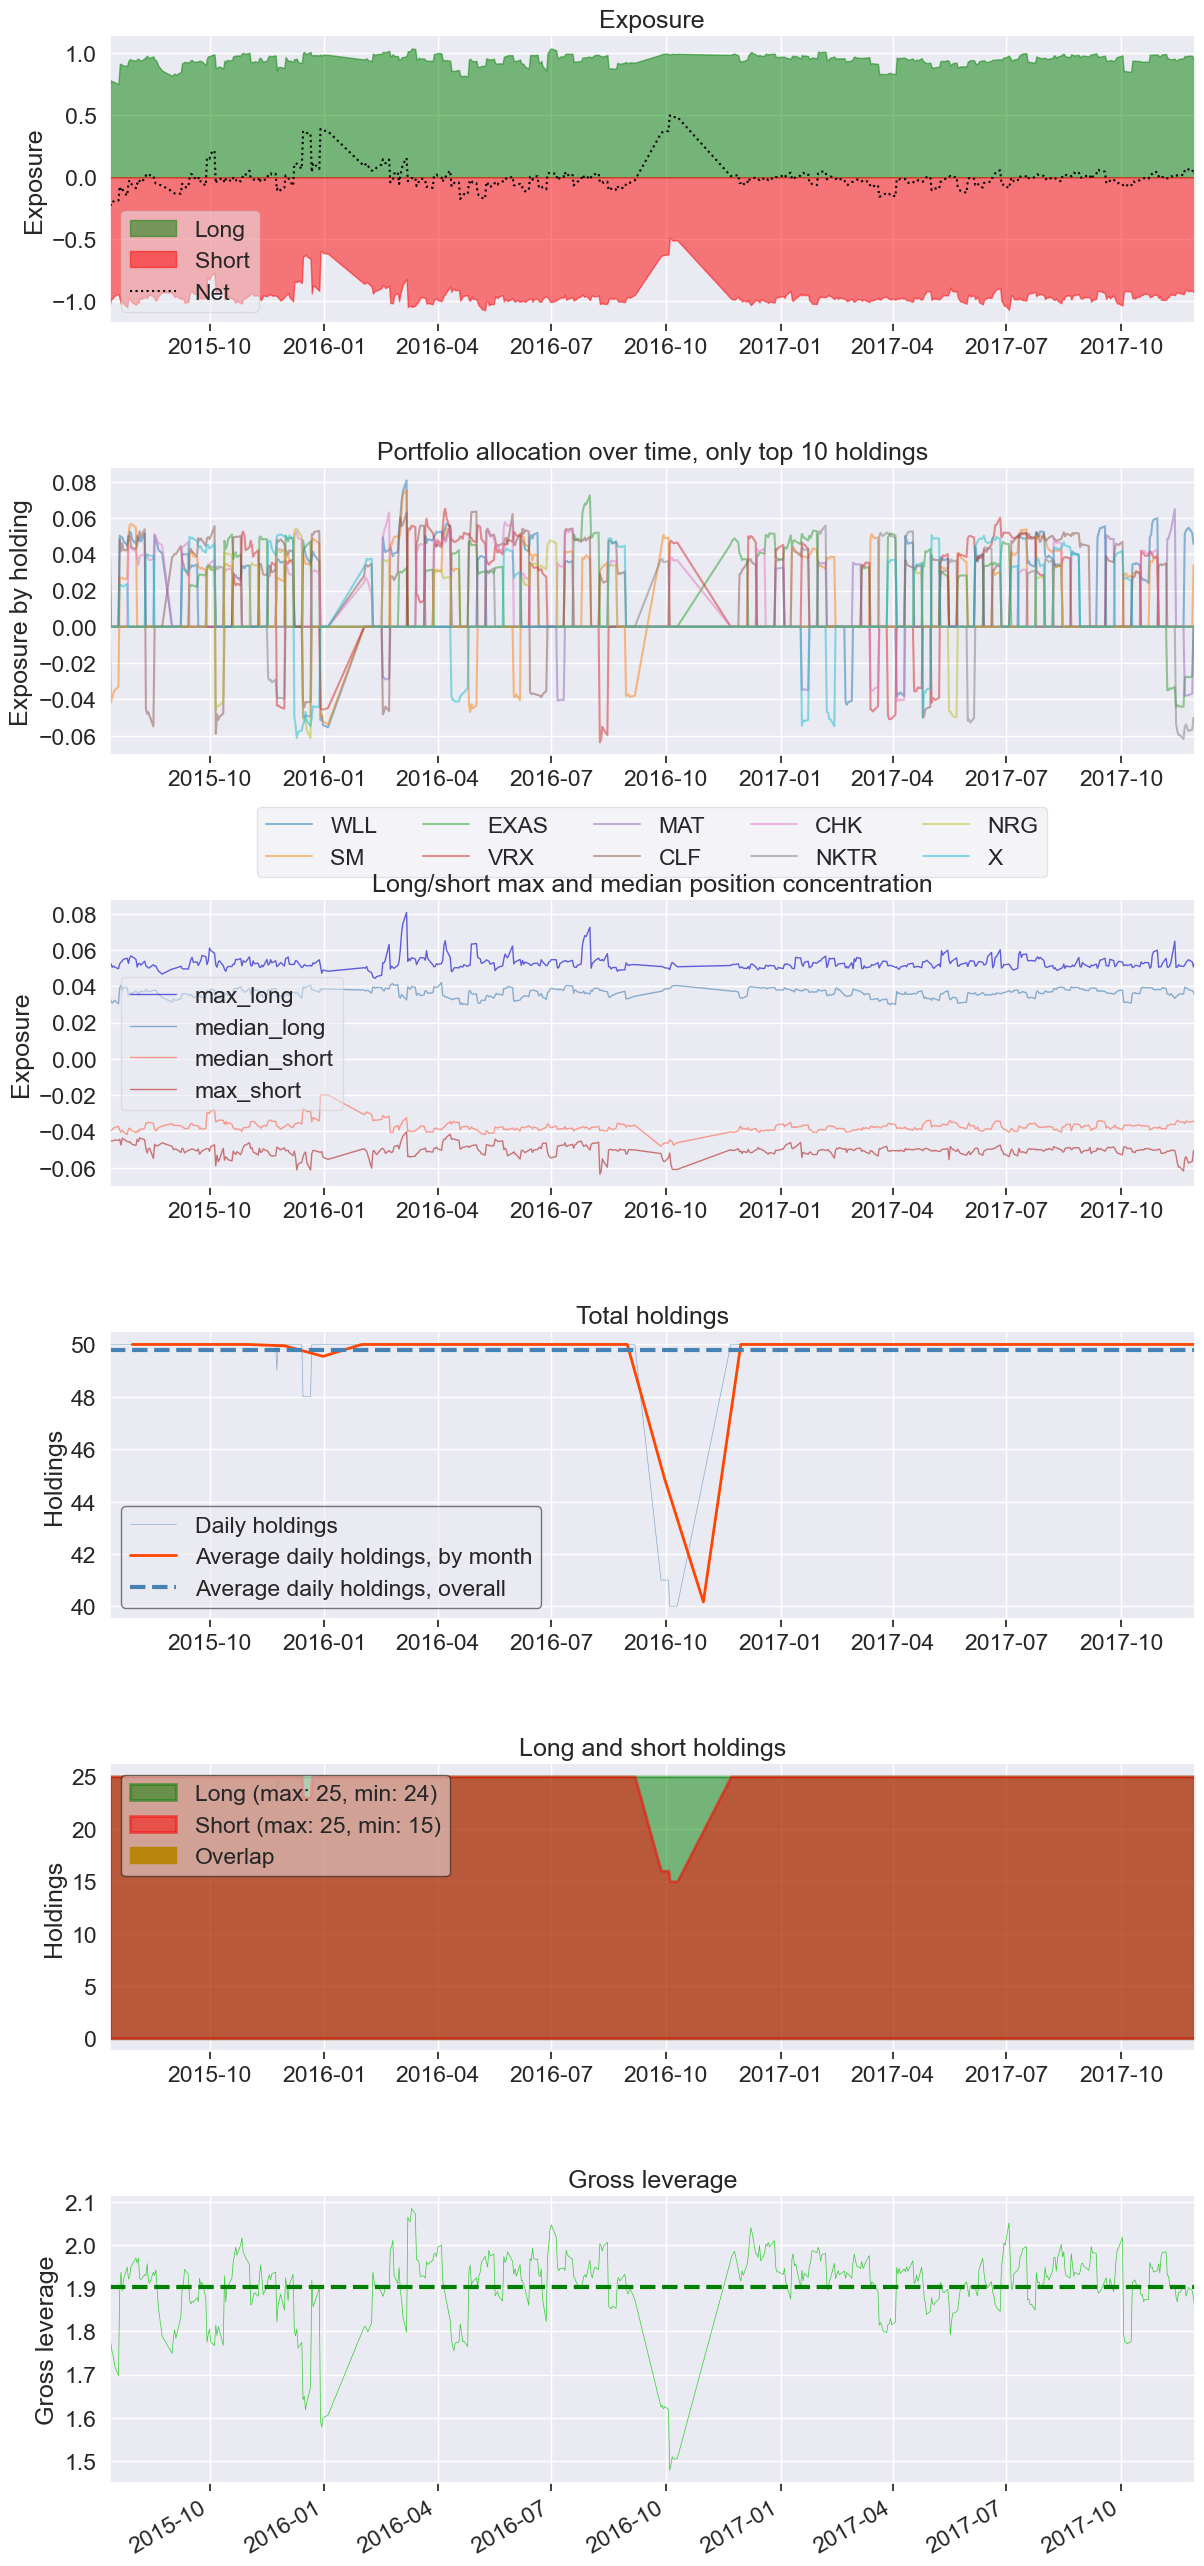

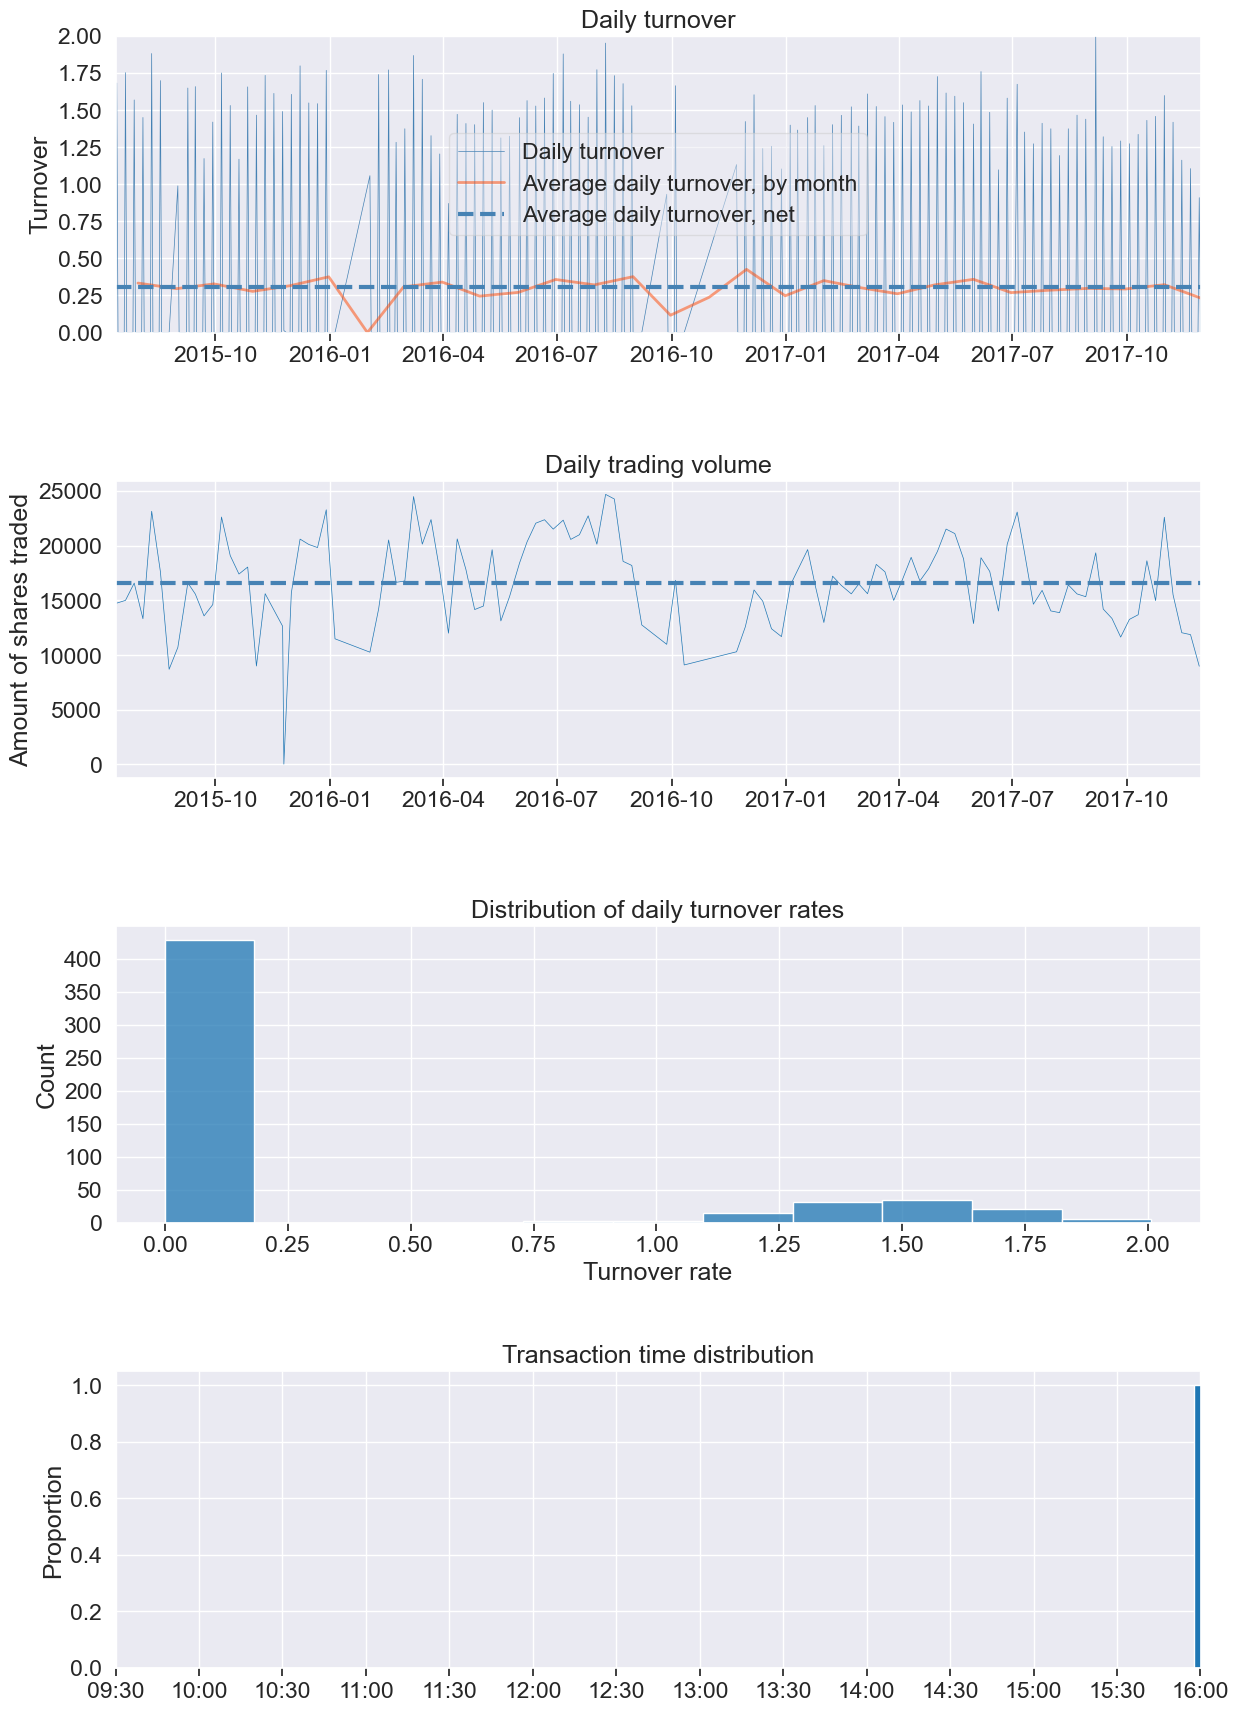

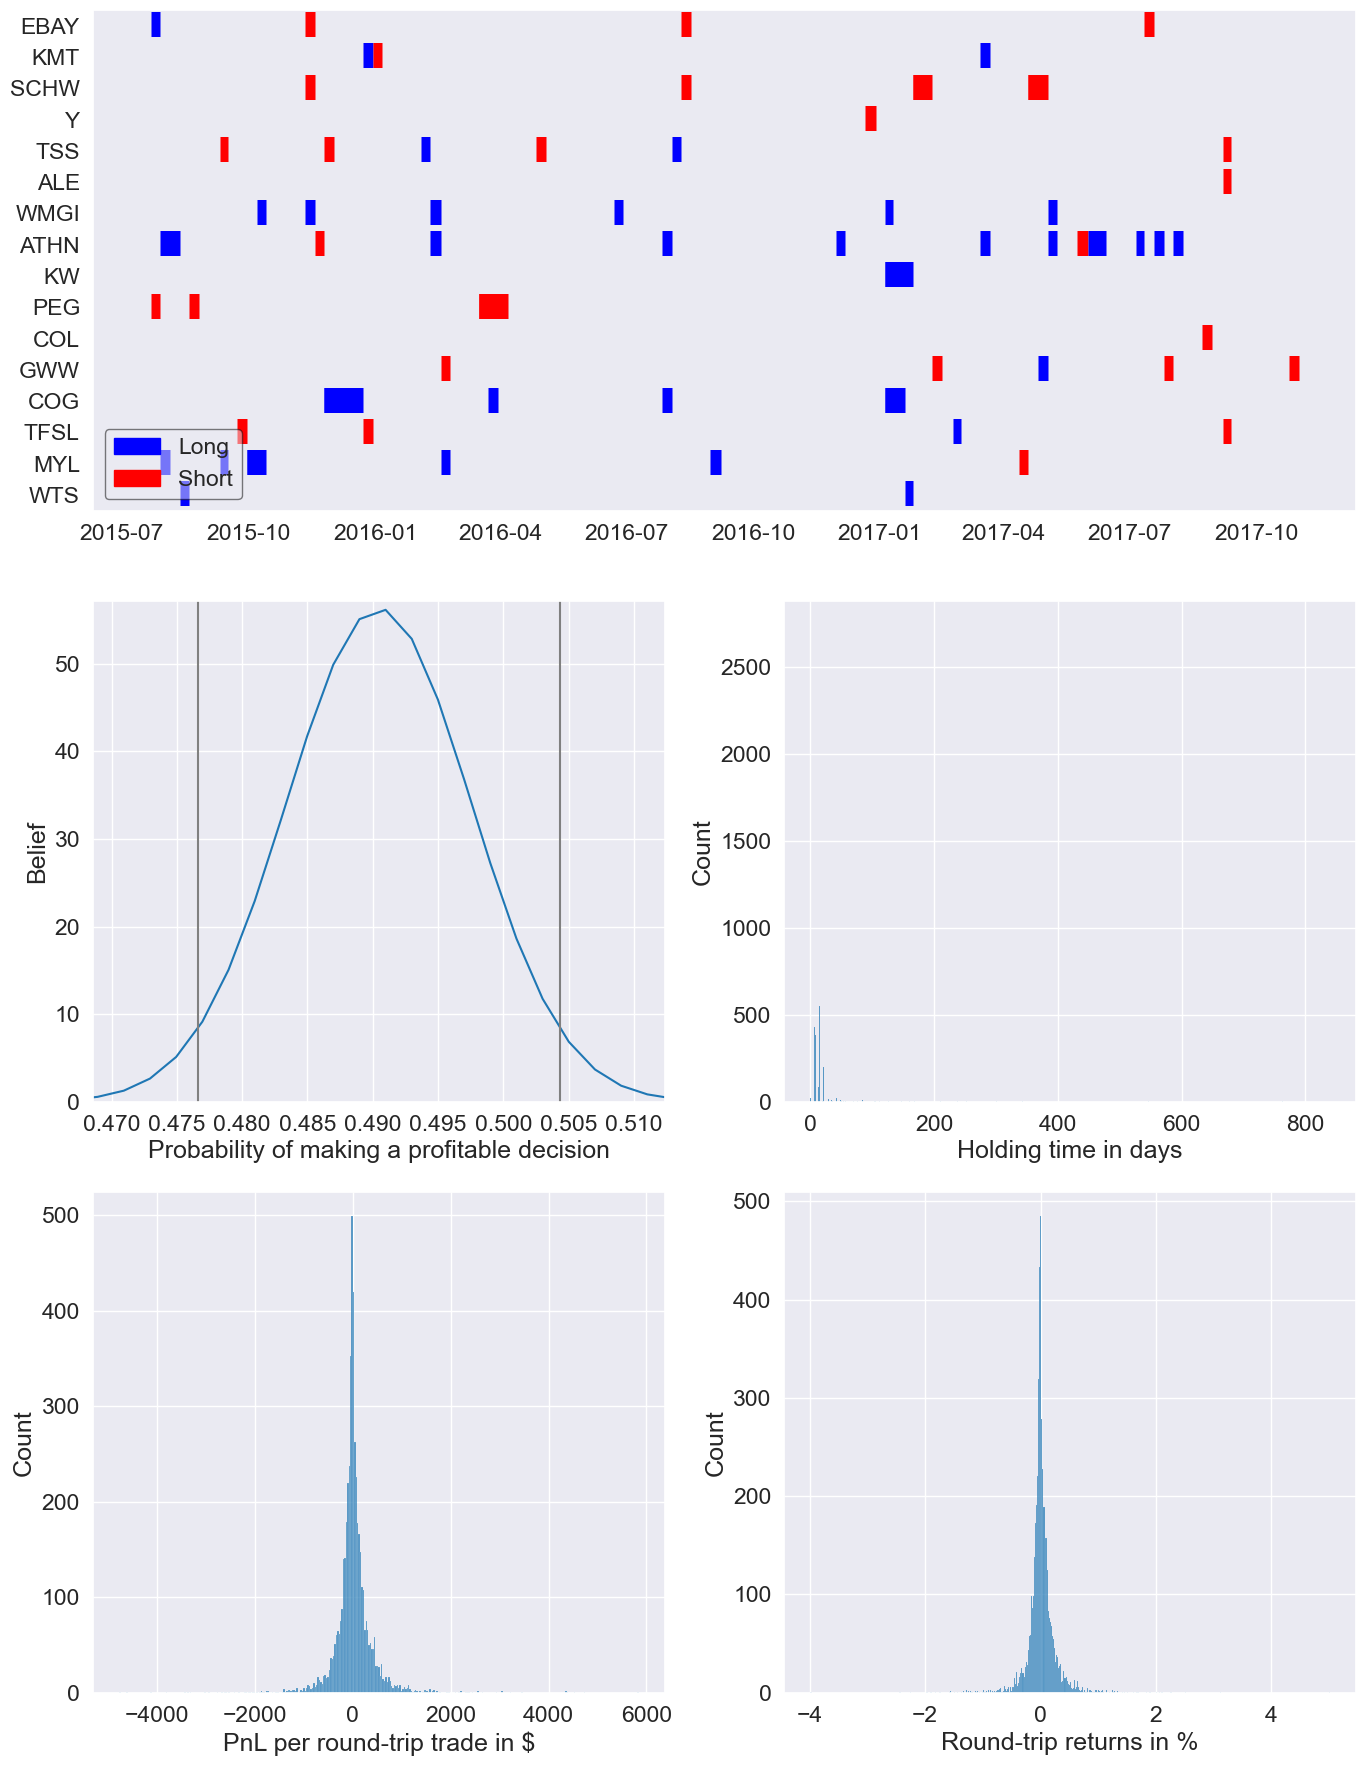

In [115]:
pf.create_full_tear_sheet(
    returns.loc["2015-07-13":,],
    positions=positions.loc["2015-07-13":,],
    transactions=transactions.loc["2015-07-13":,],
    benchmark_rets=benchmark,
    live_start_date=LIVE_DATE,
    round_trips=True,
)